In [14]:
# =========================================================
# SuperPoint Match Spatial KL-to-Uniform Analysis (FULL NOTEBOOK CODE)
# =========================================================

import numpy as np
import pandas as pd
from pathlib import Path
import cv2

# =========================================================
# CONFIGURATION (EDIT THESE)
# =========================================================

EVAL_DIRS = {
    # "original": "/home/boat/proxyISP/pytorch-superpoint/logs/eval_sl_v16.2-chroma-ISPDefaultInitialHype_original_HPatchesV4.1",
    # "visual": "/home/boat/proxyISP/pytorch-superpoint/logs/eval_sl_v16.2-chroma-HumanTunedInitialHype_replicate-s21fe_sunlit_lr0.0005_schedulerPlateauTo0.00001_bs1_ga8_adjust_defaultcolorhuesat_120000_HPatchesV4.1",
    # "feature": "/home/boat/proxyISP/pytorch-superpoint/logs/eval_sl_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.005_bothLoss_initialHypeHomoAdaptOnly_gradac187_78500_HPatchesV4.1",
    "original": "/home/boat/proxyISP/pytorch-superpoint/logs/eval_ll_v16.2-chroma-ISPDefaultInitialHype_original_HPatchesV4.1",
    "visual": "/home/boat/proxyISP/pytorch-superpoint/logs/eval_ll_v16.2-chroma-HumanTunedInitialHype_replicate-s21fe_lowlight_lr0.0005_schedulerPlateauTo0.00001_bs1_ga8_adjust_defaultcolorhuesat_denoise_45000_HPatchesV4.1",
    "feature": "/home/boat/proxyISP/pytorch-superpoint/logs/eval_ll_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_lowlight_lr0.005_bothLoss_initialHypeHomoAdaptOnly_gradac187_90200_HPatchesV4.1"
}

IMG_H = 240
IMG_W = 320

GRID_SIZE = (24, 32)   # (gy, gx)
MIN_KP_PER_CELL = 1  # occupancy threshold

OUT_CSV = "sp_occupancy_coverage.csv"

# =========================================================
# FUNCTIONS
# =========================================================

def spatial_occupancy_coverage(kps, img_size, grid_size=(3, 3), min_kp=1):
    """
    Compute occupancy-based spatial coverage.

    Coverage = (# grid cells with >= min_kp keypoints) / total cells

    Args:
        kps: (N, 2) array of keypoints (x, y)
    """
    if len(kps) == 0:
        return 0.0

    H, W = img_size
    gy, gx = grid_size

    xs = np.clip(kps[:, 0] / W, 0, 0.999999)
    ys = np.clip(kps[:, 1] / H, 0, 0.999999)

    ix = (xs * gx).astype(np.int32)
    iy = (ys * gy).astype(np.int32)

    hist = np.zeros((gy, gx), dtype=np.int32)
    for x, y in zip(ix, iy):
        hist[y, x] += 1

    occupied = (hist >= min_kp).sum()
    coverage = occupied / (gy * gx)

    return coverage


def load_matches(npz_path):
    data = np.load(npz_path, allow_pickle=True)

    if "matches" in data:
        matches = data["matches"]
    elif "matches.npy" in data:
        matches = data["matches.npy"]
    else:
        raise KeyError(f"No matches found in {npz_path}")

    matches = np.asarray(matches)
    if matches.ndim != 2 or matches.shape[1] != 4:
        raise ValueError(f"Invalid matches shape in {npz_path}: {matches.shape}")

    return matches


def process_eval_folder(eval_dir, img_size, grid_size):
    """
    Returns:
        dict[number] = {
            "C1": coverage for image 1 (RANSAC inliers),
            "C2": coverage for image 2 (RANSAC inliers),
            "num_inliers": RANSAC inlier count
        }
    """
    eval_dir = Path(eval_dir)
    pred_dir = eval_dir / "predictions"

    if not pred_dir.exists():
        raise FileNotFoundError(f"Missing predictions directory: {pred_dir}")

    results = {}

    for npz_path in sorted(pred_dir.glob("*.npz")):
        number = npz_path.stem
        if not number.isdigit():
            continue

        matches = load_matches(npz_path)
        if matches.shape[0] < 4:
            results[number] = {
                "C1": 0.0,
                "C2": 0.0,
                "num_inliers": 0
            }
            continue

        pts1 = matches[:, :2].astype(np.float32)
        pts2 = matches[:, 2:].astype(np.float32)

        _, mask = cv2.findHomography(
            pts1,
            pts2,
            method=cv2.RANSAC,
            ransacReprojThreshold=3.0,
            confidence=0.999
        )

        if mask is None:
            inliers = np.zeros(len(matches), dtype=bool)
        else:
            inliers = mask.ravel().astype(bool)

        pts1_in = pts1[inliers]
        pts2_in = pts2[inliers]

        C1 = spatial_occupancy_coverage(
            pts1_in, img_size, grid_size, MIN_KP_PER_CELL
        )
        C2 = spatial_occupancy_coverage(
            pts2_in, img_size, grid_size, MIN_KP_PER_CELL
        )

        results[number] = {
            "C1": C1,
            "C2": C2,
            "num_inliers": int(inliers.sum())
        }

    return results


# =========================================================
# RUN ANALYSIS
# =========================================================

img_size = (IMG_H, IMG_W)
all_results = {}

for eval_name, eval_path in EVAL_DIRS.items():
    print(f"[INFO] Processing {eval_name}")
    all_results[eval_name] = process_eval_folder(
        eval_path,
        img_size=img_size,
        grid_size=GRID_SIZE
    )

# =========================================================
# BUILD TABLE
# =========================================================

numbers = sorted(next(iter(all_results.values())).keys())

rows = []
for num in numbers:
    row = {"number": num}
    for eval_name, res in all_results.items():
        row[f"{eval_name}_img1_coverage"] = res[num]["C1"]
        row[f"{eval_name}_img2_coverage"] = res[num]["C2"]
        # row[f"{eval_name}_num_inliers"] = res[num]["num_inliers"]
    rows.append(row)

df_cov = pd.DataFrame(rows)

# =========================================================
# OPTIONAL: SAVE CSV
# =========================================================

# df_cov.to_csv(OUT_CSV, index=False)

df_cov.head()


[INFO] Processing original
[INFO] Processing visual
[INFO] Processing feature


,number,original_img1_coverage,original_img2_coverage,visual_img1_coverage,visual_img2_coverage,feature_img1_coverage,feature_img2_coverage
0,0,0.212240,0.210938,0.220052,0.214844,0.230469,0.226562
1,1,0.132812,0.126302,0.134115,0.125000,0.148438,0.136719
2,10,0.238281,0.250000,0.242188,0.244792,0.239583,0.239583
3,100,0.341146,0.351562,0.343750,0.361979,0.329427,0.348958
4,101,0.251302,0.243490,0.255208,0.253906,0.255208,0.251302


In [15]:
# =========================================================
# FAST MEAN / STD SUMMARY (NUMERIC ONLY)
# =========================================================

stats = {}

for col in df_cov.columns:
    if col == "number":
        continue
    stats[col] = {
        "mean": df_cov[col].mean(),
        "std": df_cov[col].std()
    }

df_stats = pd.DataFrame.from_dict(stats, orient="index")
df_stats


,mean,std
original_img1_coverage,0.129051,0.106933
original_img2_coverage,0.130691,0.108123
visual_img1_coverage,0.129244,0.107845
visual_img2_coverage,0.130739,0.109605
feature_img1_coverage,0.128906,0.106614
feature_img2_coverage,0.130912,0.108688


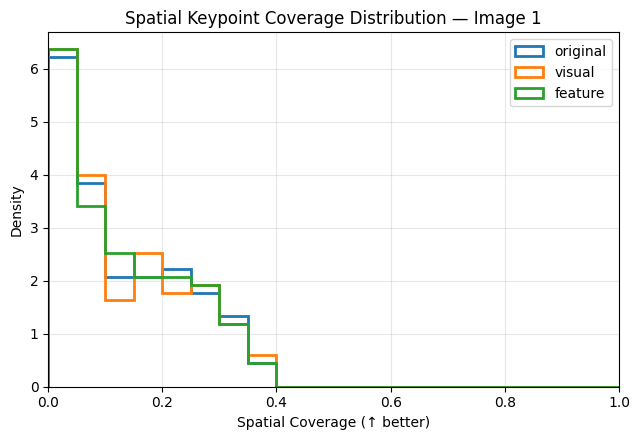

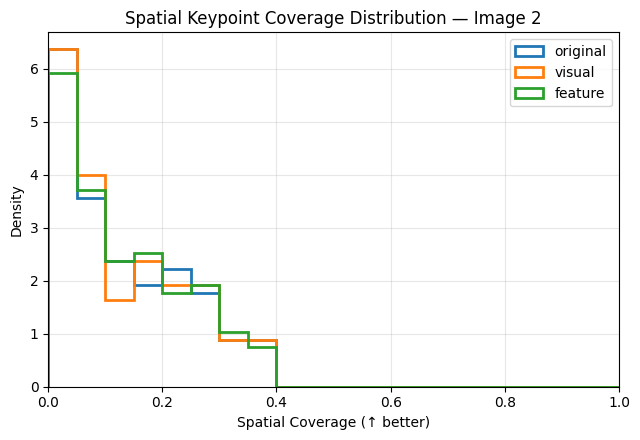

In [16]:
# =========================================================
# Spatial Keypoint Coverage — Histogram Visualization
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------

NUM_BINS = 20        # histogram resolution
COVERAGE_RANGE = (0.0, 1.0)

# ---------------------------------------------------------
# Helper: Histogram plot
# ---------------------------------------------------------

def plot_coverage_histogram(df, eval_dirs, img_idx, title_suffix):
    """
    Plot histogram of spatial coverage for a given image index.

    Args:
        df: DataFrame containing coverage columns
        eval_dirs: dict of eval configurations
        img_idx: 1 or 2
        title_suffix: string
    """

    plt.figure(figsize=(6.5, 4.5))

    for eval_name in eval_dirs.keys():
        col = f"{eval_name}_img{img_idx}_coverage"
        vals = np.asarray(df[col], dtype=np.float64)

        plt.hist(
            vals,
            bins=NUM_BINS,
            range=COVERAGE_RANGE,
            density=True,
            histtype="step",
            linewidth=2,
            label=eval_name
        )

    plt.xlabel("Spatial Coverage (↑ better)")
    plt.ylabel("Density")
    plt.title(f"Spatial Keypoint Coverage Distribution — {title_suffix}")

    plt.xlim(*COVERAGE_RANGE)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Plot Image 1 and Image 2
# ---------------------------------------------------------

plot_coverage_histogram(
    df_cov,
    EVAL_DIRS,
    img_idx=1,
    title_suffix="Image 1"
)

plot_coverage_histogram(
    df_cov,
    EVAL_DIRS,
    img_idx=2,
    title_suffix="Image 2"
)


In [17]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial import cKDTree


ANCHOR_EVAL = "feature"   # eval to measure uniqueness for
DIST_THRESH = 1.0         # pixel tolerance for "same keypoint"

OUT_CSV = "unique_keypoint_ratio.csv"

# =========================================================
# HELPERS
# =========================================================

def load_keypoints(npz_path):
    """
    Load keypoints from 'prob' key.
    Expected shape: (N, 3) -> (x, y, score)
    """
    data = np.load(npz_path, allow_pickle=True)

    if "prob" not in data:
        raise KeyError(f"'prob' not found in {npz_path}")

    kps = np.asarray(data["prob"], dtype=np.float32)
    if kps.ndim != 2 or kps.shape[1] < 2:
        raise ValueError(f"Invalid kp shape in {npz_path}: {kps.shape}")

    return kps[:, :2]  # only (x, y)


def unique_ratio(anchor_kps, candidate_kps, dist_thresh):
    """
    Compute fraction of anchor keypoints not matched
    by candidate keypoints within dist_thresh.
    """
    if len(anchor_kps) == 0:
        return 0.0

    if len(candidate_kps) == 0:
        return 1.0

    tree = cKDTree(candidate_kps)
    dists, _ = tree.query(anchor_kps, distance_upper_bound=dist_thresh)

    unmatched = np.isinf(dists)
    return unmatched.sum() / len(anchor_kps)


# =========================================================
# MAIN ANALYSIS
# =========================================================

anchor_dir = Path(EVAL_DIRS[ANCHOR_EVAL]) / "predictions"
eval_names = list(EVAL_DIRS.keys())

rows = []

for npz_path in sorted(anchor_dir.glob("*.npz")):
    number = npz_path.stem
    if not number.isdigit():
        continue

    # Load anchor kps
    try:
        anchor_kps = load_keypoints(npz_path)
    except Exception:
        continue

    # Load union of candidate kps
    candidate_kps_all = []

    for eval_name, eval_path in EVAL_DIRS.items():
        if eval_name == ANCHOR_EVAL:
            continue

        cand_npz = Path(eval_path) / "predictions" / f"{number}.npz"
        if not cand_npz.exists():
            continue

        try:
            candidate_kps_all.append(load_keypoints(cand_npz))
        except Exception:
            pass

    if len(candidate_kps_all) == 0:
        ratio = 1.0
    else:
        candidate_union = np.vstack(candidate_kps_all)
        ratio = unique_ratio(anchor_kps, candidate_union, DIST_THRESH)

    rows.append({
        "number": number,
        "anchor_eval": ANCHOR_EVAL,
        "unique_kp_ratio": ratio,
        "num_anchor_kps": len(anchor_kps),
        "num_candidate_kps": len(candidate_union) if len(candidate_kps_all) > 0 else 0
    })


# =========================================================
# BUILD DATAFRAME
# =========================================================

df_unique = pd.DataFrame(rows)

print(df_unique.describe())

# Optional save
# df_unique.to_csv(OUT_CSV, index=False)

df_unique.head()


       unique_kp_ratio  num_anchor_kps  num_candidate_kps
count       135.000000      135.000000         135.000000
mean          0.053125      403.888889         821.222222
std           0.040581       69.361875         131.722892
min           0.012320      250.000000         543.000000
25%           0.025974      360.000000         751.000000
50%           0.038647      419.000000         836.000000
75%           0.062069      471.000000         942.000000
max           0.163987      499.000000         999.000000


,number,anchor_eval,unique_kp_ratio,num_anchor_kps,num_candidate_kps
0,0,feature,0.059896,384,759
1,1,feature,0.059896,384,759
2,10,feature,0.027397,292,617
3,100,feature,0.038647,414,828
4,101,feature,0.038647,414,828
